In [32]:
import pandas as pd
import numpy as np

# The file has no header, fields are separated by multiple spaces and missing values are encoded as 'N'
column_names = [
    "Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
    "Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Vanadium_V", "Copper_Cu",
    "Cobalt_Co", "Tungsten_W", "Oxygen_O_ppm", "Titanium_Ti_ppm", "Nitrogen_N_ppm",
    "Aluminium_Al_ppm", "Boron_B_ppm", "Niobium_Nb_ppm", "Tin_Sn_ppm", "Arsenic_As_ppm",
    "Antimony_Sb_ppm", "Current_A", "Voltage_V", "AC_DC", "Electrode_Pos_Neg",
    "Heat_input_kJ_mm", "Interpass_temp_C", "Type_of_weld", "Post_weld_temp_C",
    "Post_weld_time_h", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Charpy_temp_C", "Charpy_toughness_J",
    "Hardness_kg_mm2", "FATT_50_pct", "Primary_ferrite_pct", "Ferrite_second_phase_pct",
    "Acicular_ferrite_pct", "Martensite_pct", "Ferrite_carbide_aggregate_pct", "Weld_ID"
]

df = pd.read_csv("data/welddb.data", sep=r"\s+", header=None, names=column_names, na_values="N")

print(f"Shape: {df.shape[0]} welds x {df.shape[1]} columns")
df.head()

Shape: 1652 welds x 44 columns


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Nickel_Ni,Chromium_Cr,Molybdenum_Mo,Vanadium_V,Copper_Cu,...,Charpy_temp_C,Charpy_toughness_J,Hardness_kg_mm2,FATT_50_pct,Primary_ferrite_pct,Ferrite_second_phase_pct,Acicular_ferrite_pct,Martensite_pct,Ferrite_carbide_aggregate_pct,Weld_ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


## Phase 1: Exploratory Data Analysis

The goal of this phase is to understand the database before any preprocessing. Nothing in this phase modifies `df`: every decision about cleaning, imputation or feature selection is taken afterwards, based on what we observe here.

### 1.1 General structure

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carbon_C                       1652 non-null   float64
 1   Silicon_Si                     1652 non-null   float64
 2   Manganese_Mn                   1652 non-null   float64
 3   Sulphur_S                      1648 non-null   str    
 4   Phosphorus_P                   1642 non-null   float64
 5   Nickel_Ni                      697 non-null    float64
 6   Chromium_Cr                    784 non-null    float64
 7   Molybdenum_Mo                  793 non-null    str    
 8   Vanadium_V                     928 non-null    str    
 9   Copper_Cu                      578 non-null    str    
 10  Cobalt_Co                      129 non-null    str    
 11  Tungsten_W                     75 non-null     str    
 12  Oxygen_O_ppm                   1256 non-null   float64
 13 

### 1.2 Non-numeric values

Many columns are stored as strings even though they should be numeric. We list the values that cannot be converted to numbers, to understand how they are encoded.

In [34]:
categorical_cols = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld", "Weld_ID"]
numeric_candidates = [c for c in df.columns if c not in categorical_cols]

non_numeric = {}
for col in numeric_candidates:
    converted = pd.to_numeric(df[col], errors="coerce")
    bad_values = df.loc[converted.isna() & df[col].notna(), col]
    if len(bad_values) > 0:
        non_numeric[col] = bad_values.value_counts().head(5).to_dict()

for col, values in non_numeric.items():
    print(f"{col}: {values}")

Sulphur_S: {'<0.002': 7}
Molybdenum_Mo: {'<0.01': 2}
Vanadium_V: {'<0.0005': 266, '<0.01': 31, '<5': 9, '<0.005': 2}
Copper_Cu: {'<0.01': 14}
Cobalt_Co: {'<0.01': 21}
Tungsten_W: {'<0.1': 12}
Titanium_Ti_ppm: {'<100': 50, '<0.01': 16, '<5': 2, '<10': 2}
Nitrogen_N_ppm: {'66totndres': 11, '67tot33res': 7, '61tot34res': 7, '54tot24res': 7, '52tot18res': 7}
Aluminium_Al_ppm: {'<5': 343, '<100': 38, '<0.01': 16, '<50': 6}
Boron_B_ppm: {'<5': 395, '<10': 24}
Niobium_Nb_ppm: {'<5': 284, '<100': 9, '<6': 3, '<50': 3}
Tin_Sn_ppm: {'<100': 3, '<10': 2}
Arsenic_As_ppm: {'<100': 8}
Antimony_Sb_ppm: {'<100': 5, '<10': 1}
Interpass_temp_C: {'150-200': 38}
Hardness_kg_mm2: {'203(Hv30)': 2, '157(Hv30)': 2, '144(Hv30)': 2, '154(Hv30)': 2, '224Hv10': 2}
Primary_ferrite_pct: {'<1': 2}


Most of these are detection-limit values (e.g. `<5`, `<0.01`), meaning the element is present below the measurement threshold. Others are malformed entries (e.g. `66totndres` in `Nitrogen_N_ppm`, `203(Hv30)` in `Hardness_kg_mm2`, `150-200` in `Interpass_temp_C`). They will need an explicit treatment in the preprocessing phase.

### 1.3 Missing values

Missing values are encoded as `N` in the original file. We measure how many are missing per column.

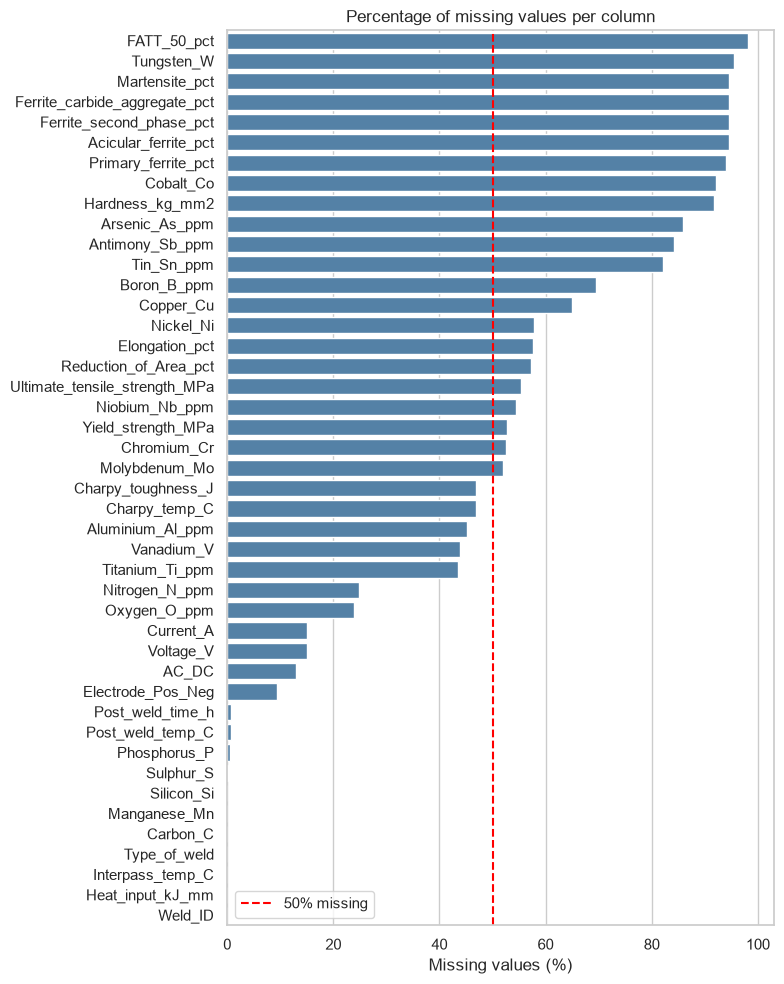

Rows with at least one missing value: 1652 / 1652
Rows with no missing value:           0 / 1652


In [35]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="50% missing")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.title("Percentage of missing values per column")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()} / {len(df)}")
print(f"Rows with no missing value:           {(~df.isna().any(axis=1)).sum()} / {len(df)}")

### 1.4 Descriptive statistics

For this summary only, we build a temporary numeric copy of the data (`df_num`) where non-convertible entries become NaN. The original `df` is left untouched.

In [36]:
df_num = df.copy()
for col in numeric_candidates:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num[numeric_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
Carbon_C,1652.0,0.075521,0.023898,0.029,0.06175,0.074,0.086,0.18
Silicon_Si,1652.0,0.328577,0.112455,0.040,0.27000,0.320,0.360,1.14
Manganese_Mn,1652.0,1.202821,0.382137,0.270,0.94000,1.270,1.440,2.25
Sulphur_S,1641.0,0.009561,0.011239,0.001,0.00600,0.007,0.010,0.14
Phosphorus_P,1642.0,0.012952,0.019627,0.002,0.00700,0.010,0.014,0.25
Nickel_Ni,697.0,0.415034,0.786951,0.000,0.00000,0.067,0.260,3.50
Chromium_Cr,784.0,2.101273,3.026548,0.000,0.00000,0.530,2.300,10.20
Molybdenum_Mo,791.0,0.480358,0.477423,0.000,0.00000,0.340,1.010,1.50
Vanadium_V,620.0,0.072443,0.096364,0.000,0.00400,0.015,0.180,0.32
Copper_Cu,564.0,0.176188,0.325897,0.000,0.00000,0.030,0.190,1.63


### 1.5 Distributions of numerical variables

We look for skewness, outliers and suspicious repeated values (sentinel or default values).

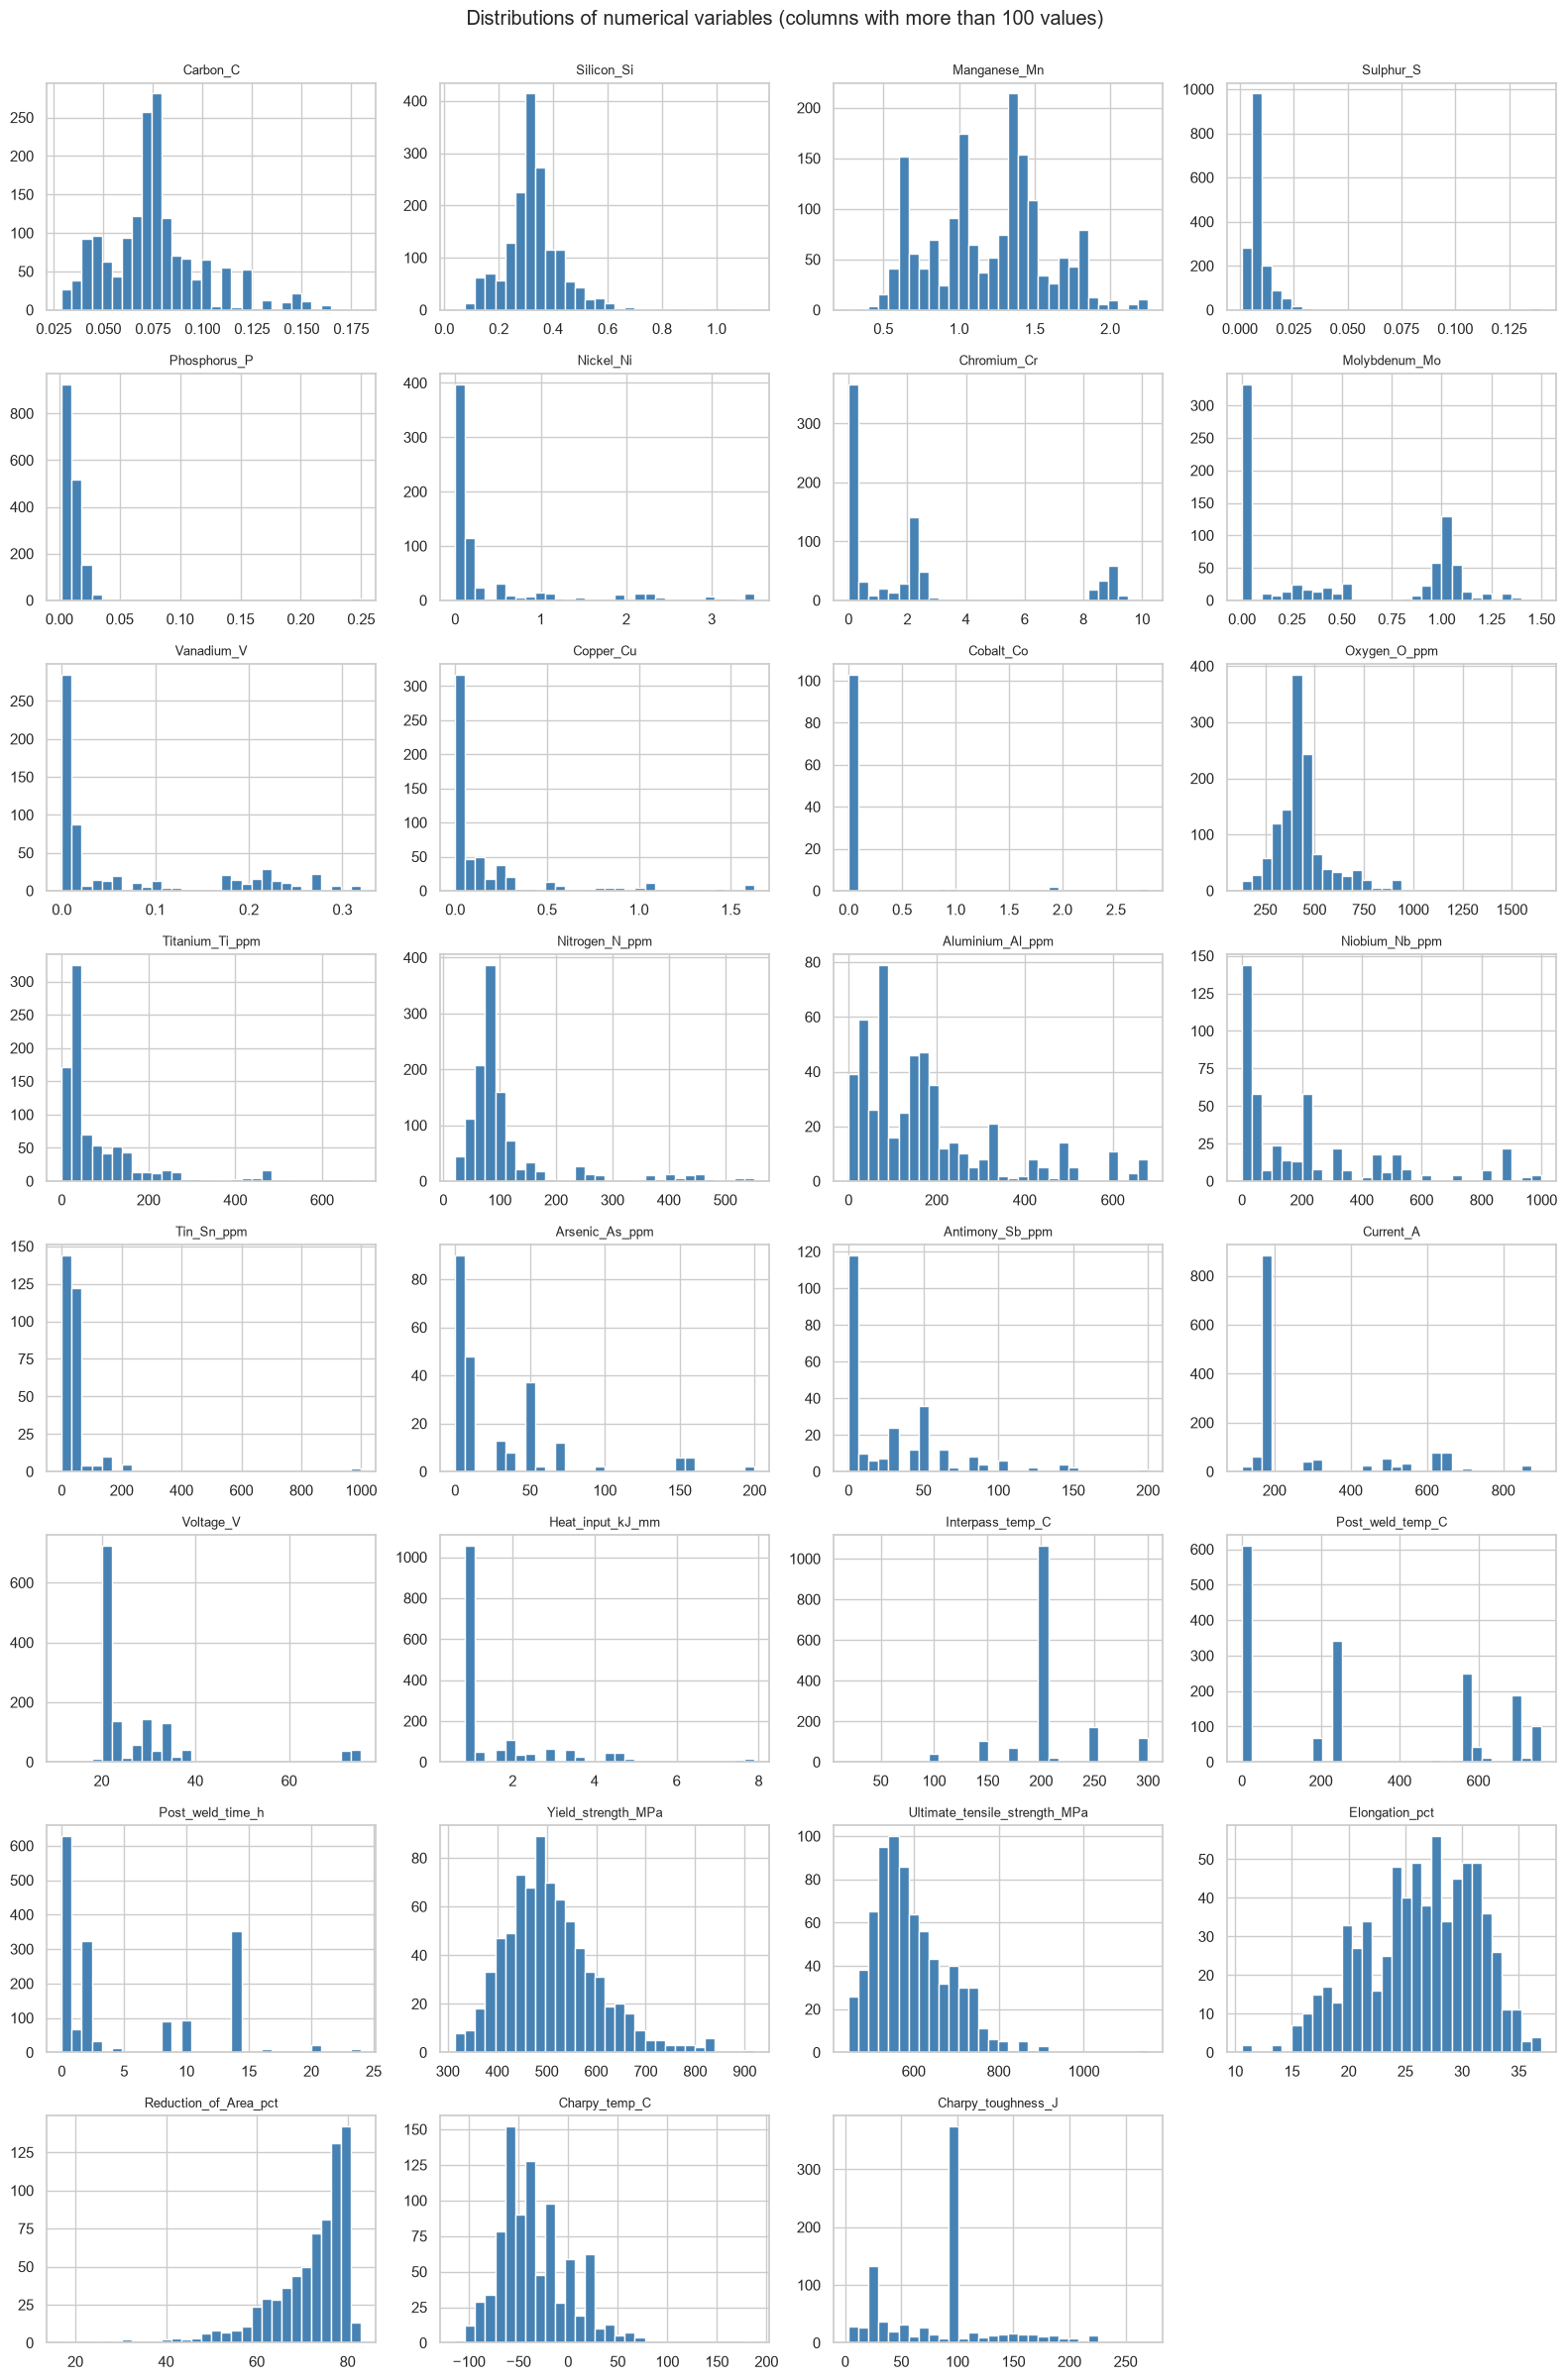

In [37]:
plot_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 100]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df_num[col].dropna(), bins=30, color="steelblue")
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
plt.suptitle("Distributions of numerical variables (columns with more than 100 values)", y=1.0)
plt.tight_layout()
plt.show()

### 1.6 Categorical variables

In [38]:
for col in ["Type_of_weld", "AC_DC", "Electrode_Pos_Neg"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

--- Type_of_weld ---
Type_of_weld
MMA      1140
SA        261
FCA        87
TSA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GTAA        4
GMAA        4 

--- AC_DC ---
AC_DC
DC     1395
NaN     215
AC       42 

--- Electrode_Pos_Neg ---
Electrode_Pos_Neg
+      1451
NaN     156
0        38
-         7 



### 1.7 Candidate target variables

The project asks us to identify which variables represent weld quality. The main candidates are the mechanical properties. We compare how many measurements each one has and how they are distributed.

,n_values,pct_missing,min,median,max
Charpy_toughness_J,879,46.8,3.0,100.0,270.0
Yield_strength_MPa,780,52.8,315.0,495.0,920.0
Ultimate_tensile_strength_MPa,738,55.3,447.0,575.5,1151.0
Elongation_pct,700,57.6,10.6,26.8,37.0
Reduction_of_Area_pct,705,57.3,17.0,75.0,83.0
Hardness_kg_mm2,80,95.2,154.0,221.0,265.0


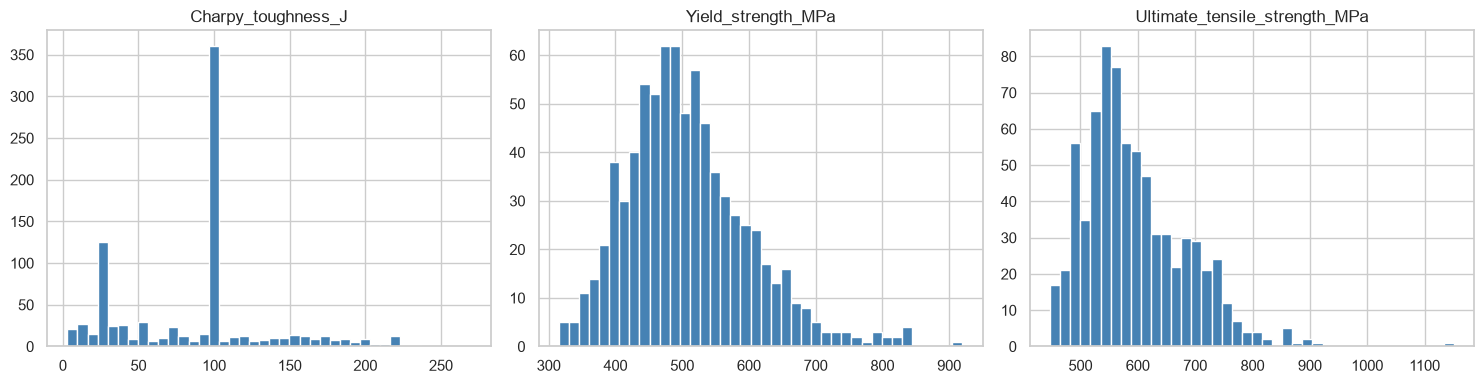

In [39]:
target_candidates = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

summary = pd.DataFrame({
    "n_values": df_num[target_candidates].notna().sum(),
    "pct_missing": (df_num[target_candidates].isna().mean() * 100).round(1),
    "min": df_num[target_candidates].min(),
    "median": df_num[target_candidates].median(),
    "max": df_num[target_candidates].max(),
})
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa"]):
    ax.hist(df_num[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Charpy_toughness_J` is the energy absorbed by the weld during an impact test, but it depends on the temperature at which the test was done (`Charpy_temp_C`). Below we check that dependence and how many tests were done at each temperature.

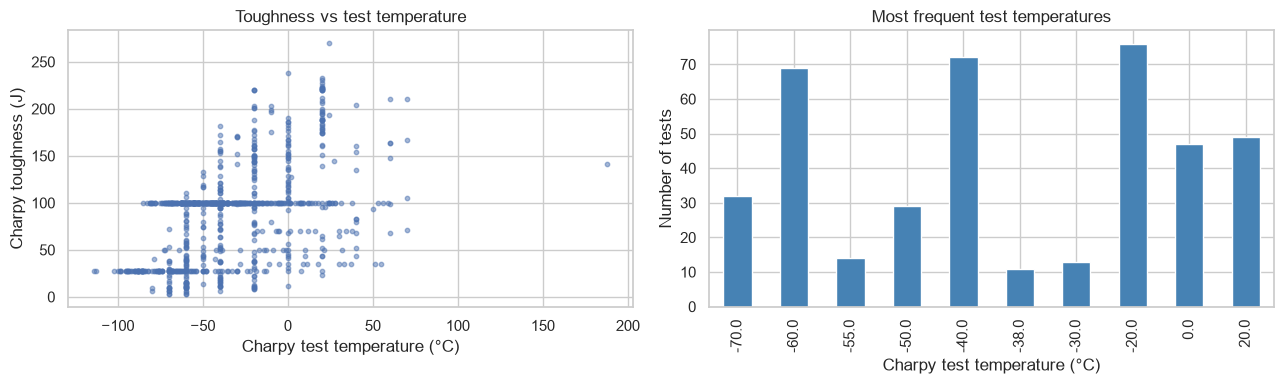

Most frequent toughness values:
Charpy_toughness_J
100.0    356
28.0     118
50.0      16
35.0      12
70.0      12


In [40]:
charpy = df_num[["Charpy_temp_C", "Charpy_toughness_J"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(charpy["Charpy_temp_C"], charpy["Charpy_toughness_J"], s=10, alpha=0.5)
axes[0].set_xlabel("Charpy test temperature (°C)")
axes[0].set_ylabel("Charpy toughness (J)")
axes[0].set_title("Toughness vs test temperature")

charpy["Charpy_temp_C"].value_counts().head(10).sort_index().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Charpy test temperature (°C)")
axes[1].set_ylabel("Number of tests")
axes[1].set_title("Most frequent test temperatures")
plt.tight_layout()
plt.show()

print("Most frequent toughness values:")
print(charpy["Charpy_toughness_J"].value_counts().head(5).to_string())

### 1.8 Correlations

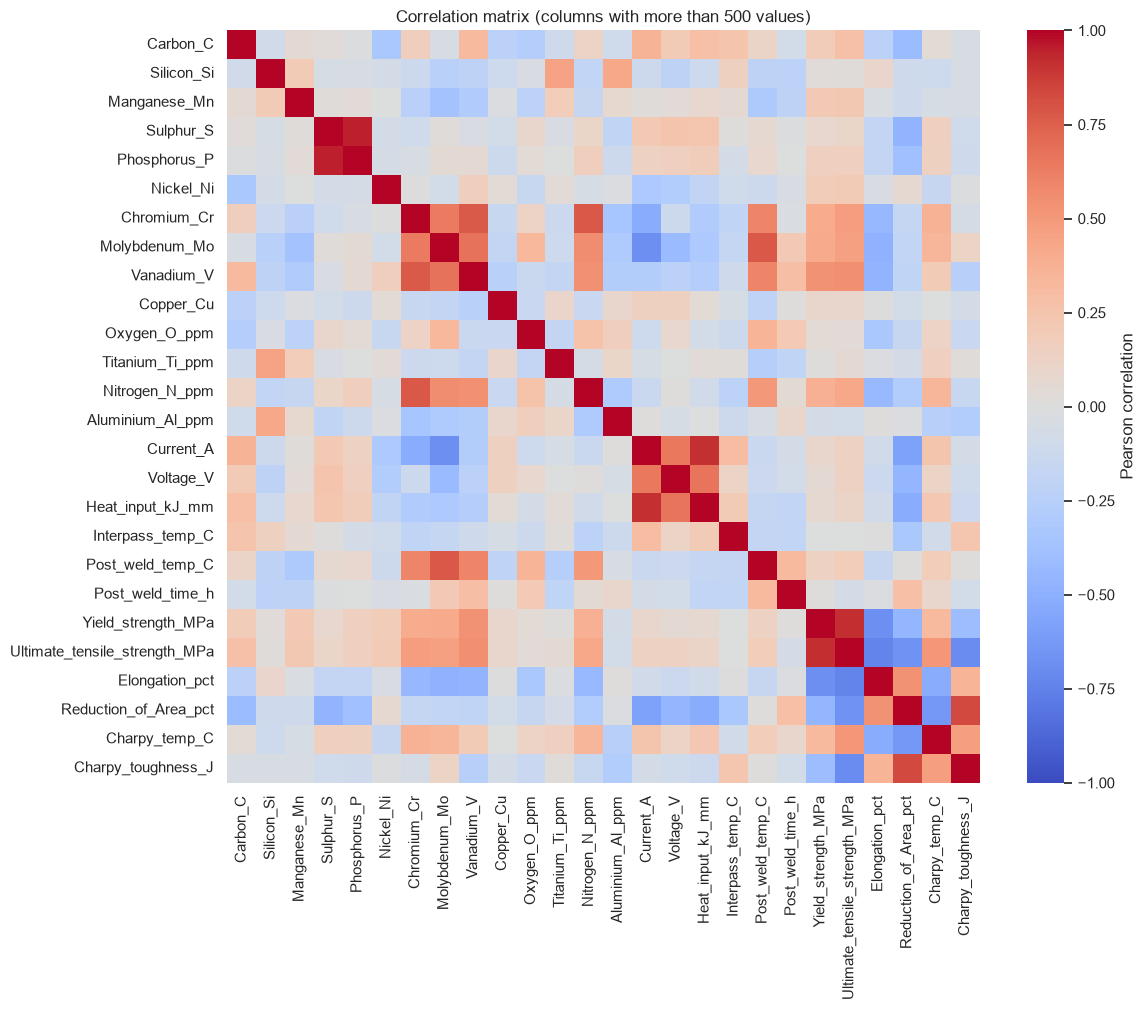

In [41]:
corr_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 500]
corr = df_num[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix (columns with more than 500 values)")
plt.tight_layout()
plt.show()

### 1.9 Duplicates and weld groups

Several rows can belong to the same weld (same composition and process, different test conditions). This matters for validation: if rows of the same weld land in both train and test sets, the performance is overestimated.

In [42]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Unique Weld_ID values: {df['Weld_ID'].nunique()} / {len(df)}")

# Same composition and process parameters shared by several rows
composition_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
                    "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
group_sizes = df.groupby(composition_cols, dropna=False).size()
print(f"Distinct composition/process combinations: {len(group_sizes)}")
print(f"Rows per combination: median {group_sizes.median():.0f}, max {group_sizes.max()}")

Fully duplicated rows: 0
Unique Weld_ID values: 1490 / 1652
Distinct composition/process combinations: 609
Rows per combination: median 2, max 20


## Phase 2: Preprocessing

Every step below is justified from what we observed in Phase 1. The preprocessing is split in two parts:
- **Deterministic cleaning** (2.1 to 2.4): rules that do not learn anything from the data (parsing strings, choosing columns, defining targets). It is safe to apply it to the whole dataset.
- **Learned transformations** (2.5): imputation, scaling and encoding. They learn parameters (medians, means, categories), so they are wrapped in a scikit-learn `ColumnTransformer` that will be fitted **only on the training folds** during cross-validation, to avoid data leakage.

### 2.1 Cleaning non-standard values

From section 1.2, the non-numeric entries follow four patterns. We convert each one to a number:

| Pattern | Example | Meaning | Treatment |
|---|---|---|---|
| `<x` | `<5`, `<0.0005` | element below the detection limit | half of the limit (`x/2`) |
| `<x` in a `_ppm` column with x < 1 | `<0.01` in `Titanium_Ti_ppm` | the limit is expressed in wt% instead of ppm | convert wt% to ppm (x 10000), then half |
| range `a-b` | `150-200` | interpass temperature range | midpoint |
| number followed by text | `66totndres`, `203(Hv30)` | total value followed by a label | leading number |

Setting detection-limit values to half of the limit is a common convention: it keeps the information "present, but very small" instead of discarding the value or treating it as a missing measurement.

In [43]:
import re


def parse_value(x, col):
    """Convert a raw entry of the weld database to a float (NaN if impossible)."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    try:
        return float(s)
    except ValueError:
        pass
    m = re.fullmatch(r"<\s*([\d.]+)", s)               # detection limit
    if m:
        limit = float(m.group(1))
        if col.endswith("_ppm") and limit < 1:           # limit given in wt% in a ppm column
            limit *= 10000
        return limit / 2
    m = re.fullmatch(r"([\d.]+)-([\d.]+)", s)           # range
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = re.match(r"([\d.]+)", s)                         # number followed by text
    if m:
        return float(m.group(1))
    return np.nan


df_clean = df.copy()
for col in numeric_candidates:
    df_clean[col] = df_clean[col].map(lambda x: parse_value(x, col))

# Sanity check: parsing must not create new missing values
new_nans = (df_clean[numeric_candidates].isna().sum() - df[numeric_candidates].isna().sum())
print("New NaN introduced by the parsing:", int(new_nans.sum()))
print("Columns still stored as strings:", [c for c in numeric_candidates if df_clean[c].dtype == object or str(df_clean[c].dtype) == "str"])

New NaN introduced by the parsing: 0
Columns still stored as strings: []


### 2.2 Features and quality variables

The preprocessing below is **independent of the choice of the quality variables**: that choice is made after the PCA, once we understand the structure of the data. For this reason:

- All the welds are kept (no row is removed because a target is missing).
- The measurements that could represent quality (mechanical properties) stay in `df_clean`, untouched and out of the features. The candidates are listed in `candidate_quality_cols`.
- `Charpy_temp_C` is not a feature for now: it is the temperature of the Charpy test, not a property of the weld. If toughness is chosen as a quality variable, it will have to be considered explicitly (it changes the toughness strongly).

### 2.3 Feature selection

- **Kept:** chemical composition and welding process parameters (the first 30 columns): they are known before the weld is tested.
- **Not features, because they are measured after welding** (they are results of the weld, not inputs, and would leak the quality): mechanical properties, hardness, FATT50 and microstructure.
- **Removed because they are almost empty:** columns with more than 80% missing values (Co, W, Sn, As, Sb). Imputing so many values would mostly invent data.
- **`Weld_ID`** is not a feature: it is an identifier.
- **Weld groups.** Rows with identical composition and process parameters are tests of the same weld. We build a group id so that cross-validation can keep them in the same fold (`GroupKFold`).
- **Rare weld types** (not MMA, SA, FCA, TSA, ShMA) are grouped into `Other`, because categories with fewer than 20 rows are too small to be useful.

In [44]:
MAX_MISSING = 0.80          # drop features with more than 80% missing values

# Composition and process parameters: first 30 columns (Carbon_C ... Post_weld_time_h)
weld_features = list(df_clean.columns[:30])
missing_ratio = df_clean[weld_features].isna().mean()
dropped_features = missing_ratio[missing_ratio > MAX_MISSING].index.tolist()
features = [c for c in weld_features if c not in dropped_features]

print(f"Dropped for more than {MAX_MISSING:.0%} missing values: {dropped_features}")
print(f"Kept {len(features)} features: {features}")

# Group id: same composition and process parameters = same weld
group_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
              "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
df_clean["Group"] = df_clean.groupby(group_cols, dropna=False).ngroup()

# Rare weld types (fewer than 20 rows) are grouped into "Other"
main_welds = ["MMA", "SA", "FCA", "TSA", "ShMA"]
df_clean["Type_of_weld"] = df_clean["Type_of_weld"].where(df_clean["Type_of_weld"].isin(main_welds), "Other")

# Candidate quality variables: kept aside, to be chosen after the PCA
candidate_quality_cols = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

Dropped for more than 80% missing values: ['Cobalt_Co', 'Tungsten_W', 'Tin_Sn_ppm', 'Arsenic_As_ppm', 'Antimony_Sb_ppm']
Kept 25 features: ['Carbon_C', 'Silicon_Si', 'Manganese_Mn', 'Sulphur_S', 'Phosphorus_P', 'Nickel_Ni', 'Chromium_Cr', 'Molybdenum_Mo', 'Vanadium_V', 'Copper_Cu', 'Oxygen_O_ppm', 'Titanium_Ti_ppm', 'Nitrogen_N_ppm', 'Aluminium_Al_ppm', 'Boron_B_ppm', 'Niobium_Nb_ppm', 'Current_A', 'Voltage_V', 'AC_DC', 'Electrode_Pos_Neg', 'Heat_input_kJ_mm', 'Interpass_temp_C', 'Type_of_weld', 'Post_weld_temp_C', 'Post_weld_time_h']


### 2.4 Feature matrix

`X` contains the features of **all** the welds. The candidate quality variables are not part of it. Once the quality variables are chosen, the rows where they are available are the labeled data, and the others are the unlabeled data of the semi-supervised part.

In [45]:
X = df_clean[features]
groups = df_clean["Group"]

print(f"X: {X.shape[0]} welds x {X.shape[1]} features, {groups.nunique()} weld groups")

# Availability of each candidate quality variable (information only, no row is removed)
pd.DataFrame({
    "n_values": df_clean[candidate_quality_cols].notna().sum(),
    "pct_missing": (df_clean[candidate_quality_cols].isna().mean() * 100).round(1),
})

X: 1652 welds x 25 features, 609 weld groups


,n_values,pct_missing
Charpy_toughness_J,879,46.8
Yield_strength_MPa,780,52.8
Ultimate_tensile_strength_MPa,738,55.3
Elongation_pct,700,57.6
Reduction_of_Area_pct,705,57.3
Hardness_kg_mm2,138,91.6


### 2.5 Missing values, categorical variables and scaling

These steps learn parameters from the data, so they are defined here as an unfitted `ColumnTransformer` and will be fitted inside the cross-validation of the models.

**Missing values**
- *Alloying elements* (`Nickel_Ni`, `Chromium_Cr`, `Molybdenum_Mo`, `Copper_Cu`): they are mostly absent in plain carbon-manganese steels, so a missing value most likely means "not added". They are filled with **0**.
- *Other numerical variables*: filled with the **median** (robust to the skewed distributions seen in section 1.5).
- In both cases a **missing indicator** column is added, so a model can still use the fact that a value was not reported.
- *Categorical variables*: missing values become their own category `missing`.

**Categorical variables.** `AC_DC`, `Electrode_Pos_Neg` and `Type_of_weld` are **one-hot encoded** (they have no natural order); unseen categories at prediction time are ignored.

**Scaling.** Variables have very different units and ranges (wt%, ppm, A, V, °C, kJ/mm), so we apply **standardization (z-score)**. It is required for PCA and for distance-based or linear models (KNN, SVM, linear regression, label propagation). Tree-based models do not need it, but it does no harm and lets us use the same preprocessing for every model. Skewed variables are not log-transformed, to keep the variables easy to interpret.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

alloy_cols_all = ["Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Copper_Cu"]
categorical_features_all = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld"]


def make_preprocessor(feature_list):
    alloy = [c for c in alloy_cols_all if c in feature_list]
    categorical = [c for c in categorical_features_all if c in feature_list]
    numeric = [c for c in feature_list if c not in alloy + categorical]
    return ColumnTransformer([
        ("alloy", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)),
            ("scale", StandardScaler()),
        ]), alloy),
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical),
    ]).set_output(transform="pandas")


preprocessor = make_preprocessor(features)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('alloy', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

### 2.6 Check of the preprocessing

To verify that the pipeline works we fit it on all the welds. **This is only an inspection** (and the input of the PCA, which is exploratory): when models are evaluated, the pipeline must be fitted on the training folds only.

In [47]:
X_t = preprocessor.fit_transform(X)

print(f"{X.shape[1]} raw features -> {X_t.shape[1]} columns after preprocessing")
print(f"Remaining NaN: {int(X_t.isna().sum().sum())}")

X_t.describe().T[["mean", "std", "min", "max"]].round(2).head(12)

25 raw features -> 52 columns after preprocessing
Remaining NaN: 0


,mean,std,min,max
alloy__Nickel_Ni,-0.0,1.0,-0.32,6.04
alloy__Chromium_Cr,-0.0,1.0,-0.43,3.94
alloy__Molybdenum_Mo,-0.0,1.0,-0.56,3.11
alloy__Copper_Cu,-0.0,1.0,-0.29,7.56
alloy__missingindicator_Nickel_Ni,0.0,1.0,-1.17,0.85
alloy__missingindicator_Chromium_Cr,0.0,1.0,-1.05,0.95
alloy__missingindicator_Molybdenum_Mo,-0.0,1.0,-1.04,0.96
alloy__missingindicator_Copper_Cu,-0.0,1.0,-1.36,0.73
numeric__Carbon_C,0.0,1.0,-1.95,4.37
numeric__Silicon_Si,-0.0,1.0,-2.57,7.22


## Phase 3: Principal Component Analysis (PCA)

The PCA is used to build intuition about the structure of the data, not to evaluate any model. It does not use any target, so it is applied to **all** the welds, on the preprocessed matrix `X_t`. It needs the three properties that the preprocessing provides: no missing values, only numbers, and a common scale (otherwise the variables with large numbers, such as the current, would dominate).

### 3.1 Input of the PCA and explained variance

`X_t` has 52 columns of three kinds: scaled numerical variables, missing indicators (0/1) and one-hot categories (0/1). The binary columns describe *which information was reported* or *which category a weld belongs to*, not a physical quantity. We therefore fit the PCA twice and compare:

- **All columns** (52).
- **Numerical and alloy variables only** (22): the physical measurements (composition and process parameters), without indicators and categories.

In [48]:
from sklearn.decomposition import PCA

numeric_cols = [c for c in X_t.columns
                if c.startswith(("alloy__", "numeric__")) and "missingindicator" not in c]
X_pca_all = X_t
X_pca_num = X_t[numeric_cols]

pca_all = PCA().fit(X_pca_all)
pca_num = PCA().fit(X_pca_num)


def n_components_for(pca, threshold):
    return int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= threshold)) + 1


pd.DataFrame({
    "n_columns": [X_pca_all.shape[1], X_pca_num.shape[1]],
    "PC1 (%)": [pca_all.explained_variance_ratio_[0] * 100, pca_num.explained_variance_ratio_[0] * 100],
    "PC2 (%)": [pca_all.explained_variance_ratio_[1] * 100, pca_num.explained_variance_ratio_[1] * 100],
    "PC1+PC2 (%)": [pca_all.explained_variance_ratio_[:2].sum() * 100, pca_num.explained_variance_ratio_[:2].sum() * 100],
    "components for 80%": [n_components_for(pca_all, 0.80), n_components_for(pca_num, 0.80)],
    "components for 90%": [n_components_for(pca_all, 0.90), n_components_for(pca_num, 0.90)],
}, index=["All columns", "Numerical and alloy only"]).round(1)

,n_columns,PC1 (%),PC2 (%),PC1+PC2 (%),components for 80%,components for 90%
All columns,52,15.8,11.4,27.2,14,20
Numerical and alloy only,22,18.2,14.2,32.4,11,15


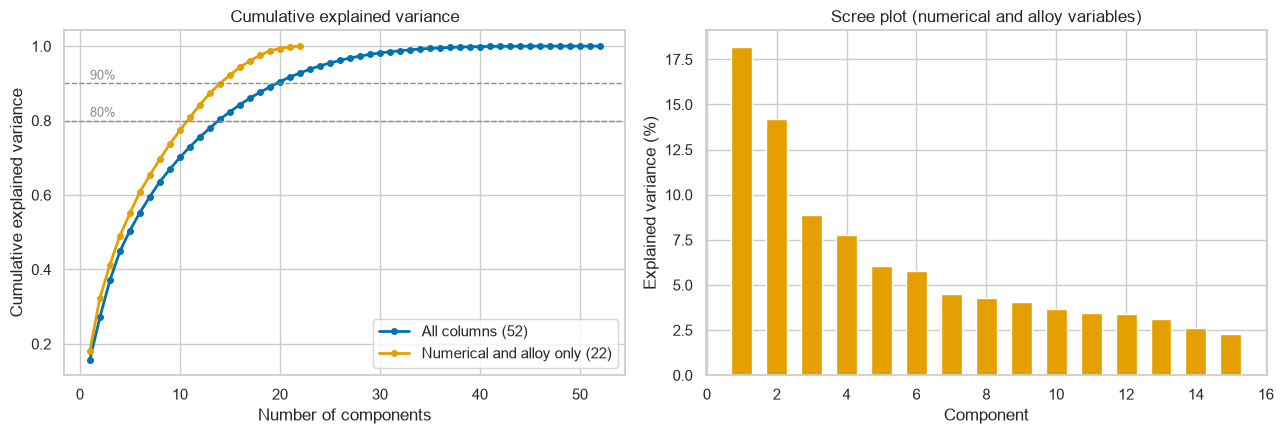

In [49]:
BLUE, ORANGE, GREY = "#0072B2", "#E69F00", "#8c8c8c"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for pca, label, color in [(pca_all, f"All columns ({X_pca_all.shape[1]})", BLUE),
                          (pca_num, f"Numerical and alloy only ({X_pca_num.shape[1]})", ORANGE)]:
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    axes[0].plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=4, linewidth=2,
                 color=color, label=label)
for threshold in (0.80, 0.90):
    axes[0].axhline(threshold, color=GREY, linestyle="--", linewidth=1)
    axes[0].text(1, threshold + 0.01, f"{threshold:.0%}", color=GREY, fontsize=9)
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("Cumulative explained variance")
axes[0].legend(loc="lower right")

n_show = 15
axes[1].bar(range(1, n_show + 1), pca_num.explained_variance_ratio_[:n_show] * 100, color=ORANGE, width=0.6)
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Explained variance (%)")
axes[1].set_title("Scree plot (numerical and alloy variables)")

plt.tight_layout()
plt.show()

### 3.2 Welds in the plane of the first two components

From here on we use the numerical and alloy version, which is the one that can be interpreted physically. The same plane is colored four ways: by weld type, by two candidate quality variables (yield strength and Charpy toughness) and by whether the heat input is exactly 1.0 kJ/mm. Welds without a measurement are shown in grey. The quality variables are used here only as colors: the choice of the quality variables is made later.

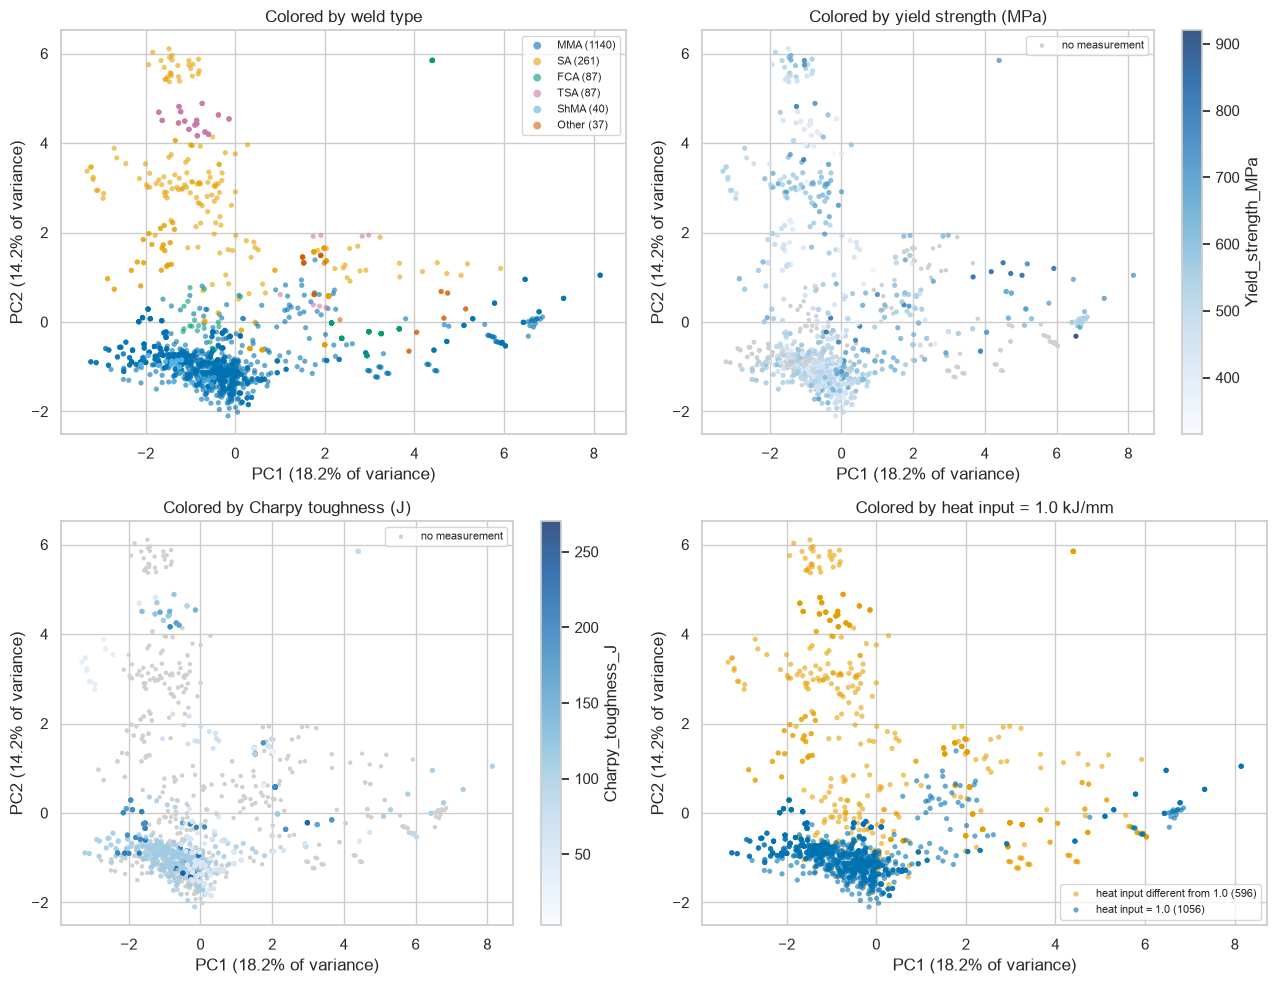

In [50]:
Z = pd.DataFrame(pca_num.transform(X_pca_num)[:, :4], columns=["PC1", "PC2", "PC3", "PC4"], index=X_t.index)
var_pct = pca_num.explained_variance_ratio_ * 100

weld_order = main_welds + ["Other"]
weld_colors = dict(zip(weld_order, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# a) weld type
ax = axes[0, 0]
for weld in weld_order:
    mask = df_clean["Type_of_weld"] == weld
    ax.scatter(Z.loc[mask, "PC1"], Z.loc[mask, "PC2"], s=14, alpha=0.6, color=weld_colors[weld],
               label=f"{weld} ({mask.sum()})", edgecolor="none")
ax.set_title("Colored by weld type")
ax.legend(fontsize=8, markerscale=1.5)

# b) and c) continuous candidate quality variables
for ax, col, title in [(axes[0, 1], "Yield_strength_MPa", "Colored by yield strength (MPa)"),
                       (axes[1, 0], "Charpy_toughness_J", "Colored by Charpy toughness (J)")]:
    has_value = df_clean[col].notna()
    ax.scatter(Z.loc[~has_value, "PC1"], Z.loc[~has_value, "PC2"], s=10, color="#d0d0d0", edgecolor="none",
               label="no measurement")
    sc = ax.scatter(Z.loc[has_value, "PC1"], Z.loc[has_value, "PC2"], s=14, c=df_clean.loc[has_value, col],
                    cmap="Blues", edgecolor="none", alpha=0.8)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")

# d) heat input equal to 1.0
ax = axes[1, 1]
is_one = df_clean["Heat_input_kJ_mm"] == 1.0
ax.scatter(Z.loc[~is_one, "PC1"], Z.loc[~is_one, "PC2"], s=14, alpha=0.6, color=ORANGE, edgecolor="none",
           label=f"heat input different from 1.0 ({(~is_one).sum()})")
ax.scatter(Z.loc[is_one, "PC1"], Z.loc[is_one, "PC2"], s=14, alpha=0.6, color=BLUE, edgecolor="none",
           label=f"heat input = 1.0 ({is_one.sum()})")
ax.set_title("Colored by heat input = 1.0 kJ/mm")
ax.legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}% of variance)")
    ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}% of variance)")
plt.tight_layout()
plt.show()

### 3.3 Loadings: what the components represent

The loadings are the weights of each original variable in a component. A large positive or negative weight means that the variable contributes strongly to it; variables with weights of the same sign move together along that component.

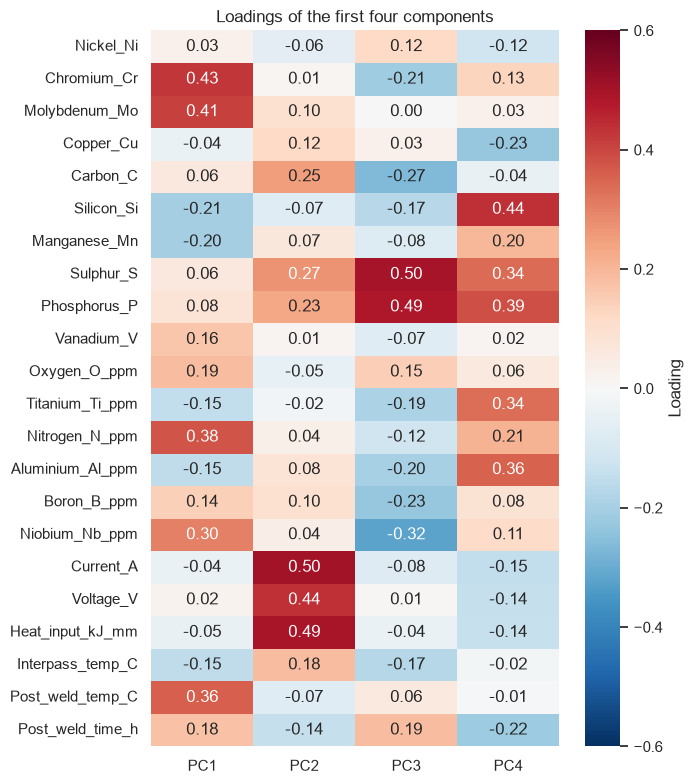

PC1: Chromium_Cr (+0.43), Molybdenum_Mo (+0.41), Nitrogen_N_ppm (+0.38), Post_weld_temp_C (+0.36), Niobium_Nb_ppm (+0.30)
PC2: Current_A (+0.50), Heat_input_kJ_mm (+0.49), Voltage_V (+0.44), Sulphur_S (+0.27), Carbon_C (+0.25)
PC3: Sulphur_S (+0.50), Phosphorus_P (+0.49), Niobium_Nb_ppm (-0.32), Carbon_C (-0.27), Boron_B_ppm (-0.23)
PC4: Silicon_Si (+0.44), Phosphorus_P (+0.39), Aluminium_Al_ppm (+0.36), Sulphur_S (+0.34), Titanium_Ti_ppm (+0.34)


In [51]:
feature_names = [c.split("__")[-1] for c in numeric_cols]
loadings = pd.DataFrame(pca_num.components_[:4].T, index=feature_names, columns=["PC1", "PC2", "PC3", "PC4"])

plt.figure(figsize=(7, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            cbar_kws={"label": "Loading"})
plt.title("Loadings of the first four components")
plt.tight_layout()
plt.show()

for pc in loadings.columns:
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(5)
    print(f"{pc}: " + ", ".join(f"{name} ({value:+.2f})" for name, value in top.items()))

### 3.4 Link between the components and the candidate quality variables

Correlation of each component with the candidate quality variables and with the heat-input indicator. Each correlation uses only the welds where the variable is available, so the number of welds differs. These are linear correlations and are only indicative.

In [52]:
quality_for_pca = ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa", "Elongation_pct"]

rows = {}
for col in quality_for_pca:
    mask = df_clean[col].notna()
    rows[col] = {"n": int(mask.sum())} | {pc: np.corrcoef(Z.loc[mask, pc], df_clean.loc[mask, col])[0, 1]
                                          for pc in Z.columns}
rows["Heat input = 1.0 (indicator)"] = {"n": len(df_clean)} | {
    pc: np.corrcoef(Z[pc], (df_clean["Heat_input_kJ_mm"] == 1.0).astype(float))[0, 1] for pc in Z.columns}

pd.DataFrame(rows).T.round(2)

,n,PC1,PC2,PC3,PC4
Charpy_toughness_J,879.0,-0.12,-0.10,-0.03,-0.10
Yield_strength_MPa,780.0,0.31,0.14,-0.19,0.17
Ultimate_tensile_strength_MPa,738.0,0.37,0.22,-0.25,0.19
Elongation_pct,700.0,-0.43,-0.17,0.14,-0.15
Heat input = 1.0 (indicator),1652.0,-0.21,-0.66,-0.06,0.05


### 3.5 Interpretation

**Dimensionality.** There is no dominant direction: the first two components explain only about 32% of the variance, and 11 components (out of 22) are needed for 80% and 15 for 90%. The data are not low-dimensional, so the PCA is not useful to reduce the number of features here; it is useful to understand the structure.

**Missing indicators.** When they are included, the first components are dominated by the missing indicators: the PCA mostly separates welds by *which elements were reported* (different studies report different elements), not by metallurgy. This is why the interpretation uses only the numerical and alloy variables.

**What the components represent** (numerical and alloy version):
- **PC1 (about 18%): alloy content and heat treatment.** Chromium, molybdenum, nitrogen, niobium and post-weld temperature on one side; silicon and manganese on the other. FCA welds and the rare weld types are high on this component.
- **PC2 (about 14%): welding energy.** Current, heat input and voltage. Submerged-arc welds (SA, TSA) are high, manual welds (MMA, ShMA) are low.
- **PC3 (about 9%): impurities.** Sulphur and phosphorus, which vary together (correlation 0.95 in the EDA).
- **PC4 (about 8%):** silicon, phosphorus, aluminium, sulphur and titanium.

The weld families separate in the PC1-PC2 plane. This supports using `GroupKFold` and suggests that a model may learn the weld family rather than the effect of the variables.

**Heat input.** The indicator "heat input = 1.0" has a correlation of about -0.66 with PC2: the value 1.0 is the manual-welding side of the energy axis, so it is largely redundant with the weld type. It still carries information for the other processes (values such as 2.0, 3.3, 4.6), so it is kept for now; the decision can be revisited with the team.

**Link with quality (indicative).** Strength and elongation are related to PC1 (yield +0.31, tensile +0.37, elongation -0.43): more alloyed and heat-treated welds are stronger and less ductile, which is the strength/ductility trade-off already seen in the EDA. Charpy toughness is only weakly related to any of the first four components (largest absolute correlation about 0.12): toughness is not explained by the main directions of variance of composition and process. This suggests that toughness is harder to predict from these variables (probably non-linear relations and interactions, plus the effect of the test temperature and of the 28 J values), whereas strength and elongation have a clearer link with composition.

**Consequences for the next steps.**
- Standardization is justified: without it the current and the voltage would dominate the first components.
- The quality variables will be chosen taking this into account: the strength variables are better linked to the features than the toughness.
- The PCA components are not used as inputs of the models; the original variables are kept for interpretability.

## Phase 4: Quality variables and prediction strategy

### 4.1 What represents weld quality

A good weld has to be **strong** and **tough** at the same time. These are two different properties, measured with different tests, and they move in opposite directions: the correlation between Charpy toughness and tensile strength is -0.70 (and -0.41 with yield strength). A single number cannot describe quality, so we define quality along **two dimensions**, each with its own variables and its own model:

| Dimension | Quality variables | Role |
|---|---|---|
| **Strength** (main) | `Yield_strength_MPa`, `Ultimate_tensile_strength_MPa`, `Elongation_pct` | Main objective |
| **Toughness** (secondary) | `Charpy_toughness_J` | Second objective |

### 4.2 Why these variables

**Strength is the main objective** because the data support it best:
- 665 welds have the three measurements together, belonging to 465 independent weld groups.
- The three variables are strongly related (yield-tensile 0.91, yield-elongation -0.71, tensile-elongation -0.74), so predicting them together in one multi-target model is natural. Yield and tensile strength measure the resistance; elongation measures the ductility and shows the strength/ductility trade-off.
- There is no test-temperature effect and no suspicious repeated value.
- The PCA shows a clear link with composition: they are related to PC1, the alloy content and heat treatment axis (yield +0.31, tensile +0.37, elongation -0.43).

**Toughness is the secondary objective** because it is the standard criterion of weld quality (resistance to brittle fracture, relevant for the cold-weather applications of the project, such as wind turbine tubes), but it is harder to model:
- Toughness depends strongly on the test temperature (median 39 J at -60 °C, 188 J at +20 °C), so `Charpy_temp_C` must be taken into account.
- 356 of the 879 values are exactly 100 J at every test temperature, which is physically implausible (probably a default value); 118 values are 28 J, concentrated at low temperatures (probably an acceptance threshold). If the 100 J values are removed, 523 welds remain (200 independent groups), and 23% of them are 28 J.
- In the PCA it is only weakly related to the main components (largest absolute correlation 0.12): it is not explained by the main directions of variance of composition and process. We expect weaker results than for strength.

### 4.3 Why two models and not one

Charpy and strength are measured on almost disjoint sets of welds: only 144 welds have Charpy, yield and tensile together (35 if the Charpy temperature is also fixed). A single multi-target model would keep less than 10% of the data. Two models let each one use all the welds where its own variables are available, and the two predictions can still be compared to discuss the strength/toughness trade-off.

### 4.4 What is discarded, and why

- **Hardness** (80 values) and the **microstructure** variables and FATT50 (fewer than 100 values): too few measurements.
- **Reduction of area** (705 values): it is a result of the same tensile test and correlates 0.83 with Charpy toughness; it is not an input and does not add a different quality dimension.
- **Weld_ID** and **Group**: identifiers, not variables.

### 4.5 Prediction strategy

1. **Features:** the 25 composition and process variables, preprocessed by `preprocessor` (Phase 2). For the toughness model, `Charpy_temp_C` is added as a feature, because it is a known condition of the test and changes the result strongly.
2. **Strength model:** multi-target regression of the three variables on the 665 welds that have all of them.
3. **Toughness model:** regression of `Charpy_toughness_J` on the welds with a Charpy value and a test temperature. The treatment of the 100 J and 28 J values is **still to be decided** (and checked against the documentation of the database): options are to remove only the 100 J values, to remove both, or to move to a classification (toughness above or below a threshold).
4. **Validation:** cross-validation with `GroupKFold` on the `Group` column (welds with identical composition and process parameters stay in the same fold). Without it, rows of the same weld would appear in the training and test sets and the scores would be overestimated. The preprocessing must be inside a `Pipeline`, so that it is fitted on the training folds only.
5. **Metrics:** R², RMSE and MAE for each target. The targets have different units, so they are evaluated separately.
6. **Unlabeled data:** the welds without the quality measurements (about 840 without any strength measurement and about 770 without Charpy) have all the input features and are the material for the semi-supervised part. Their distribution differs from the labeled welds (for example, nickel is more frequent and higher among them), so pseudo-labels on nickel-rich welds are extrapolations.

### 4.6 Limitations to keep in mind

- Only 465 (strength) and about 200 (toughness) independent welds: cross-validation estimates will be noisy and complex models are risky.
- The weld types are unbalanced (about 70% of the strength data are MMA welds): a model may learn the weld family rather than the effect of the variables.
- The values 100 J and 28 J in the Charpy data are not real measurements and may bias the toughness model.
- Linear correlations and the PCA only describe linear structure; the relations with the quality variables are probably non-linear.